# Diffusion Model Training (next-day conditional)

Train a conditional diffusion model that learns the next-day IV surface
distribution given the current-day surface,

- historical: consecutive trading days from the chronologically-ordered
  training slice.
- heston / sabr: consecutive simulation steps within paths assigned
  to the training split (paths are disjoint between train and validation).
                                                 

In [ ]:
import json
import time
from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from implied_volatility_diffusion import (
    ArbitragePenalty,
    ArbitrageWeights,
    DiffusionLoss,
    DiffusionLossConfig,
    DiffusionModel,
    UnifiedGrid,
    UNet,
    VPNoiseScheduler,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})


def _select_device() -> torch.device:
    """Prefer Apple Silicon MPS, then CUDA, then CPU."""
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
print(f"compute device: {DEVICE}")

In [2]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATASET_ROOT = REPO_ROOT / "data" / "processed" / "forecasting_dataset"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
print("unified grid:", GRID.shape)

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(
        f"missing {DATASET_ROOT / 'manifest.json'}; "
        "run notebooks/unified_surface_pipeline.ipynb first to materialise the training pool"
    )

unified grid: (41, 40)


##  Load training and validation pair stacks



In [3]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
print("dataset manifest:", json.dumps(manifest, indent=2))

TRAIN_DIR = REPO_ROOT / manifest["splits"]["train"]
VAL_DIR = REPO_ROOT / manifest["splits"]["val"]
normalizer_stats = np.load(DATASET_ROOT / "normalizer.npz")
normalizer_mean = normalizer_stats["mean"].astype(np.float32)
normalizer_std = normalizer_stats["std"].astype(np.float32)
normalizer_iv_floor = float(normalizer_stats.get("iv_floor", 1e-8))
normalizer_stats.close()


#  Training pair stack
pair_curr = np.load(TRAIN_DIR / "pair_curr.npy").astype(np.float32)  # S_t
pair_next = np.load(TRAIN_DIR / "pair_next.npy").astype(np.float32)  # S_{t+1}
training_sources = np.load(TRAIN_DIR / "pair_sources.npy")
assert pair_curr.shape == pair_next.shape, f"train curr/next shape mismatch: {pair_curr.shape} vs {pair_next.shape}"
n_total = int(pair_curr.shape[0])

#  Validation pair stack (held out, not used to update weights)
val_pair_curr = np.load(VAL_DIR / "pair_curr.npy").astype(np.float32)
val_pair_next = np.load(VAL_DIR / "pair_next.npy").astype(np.float32)
val_pair_sources = np.load(VAL_DIR / "pair_sources.npy")
assert val_pair_curr.shape == val_pair_next.shape


historic_surfaces = np.load(DATASET_ROOT / "historical" / "surfaces.npy")
heston_surfaces = np.load(DATASET_ROOT / "heston" / "surfaces.npy")  # (n_paths, n_steps, K, T)
sabr_surfaces = np.load(DATASET_ROOT / "sabr" / "surfaces.npy")  # (n_paths, n_steps, K, T)

historic_dates = pd.DatetimeIndex(np.load(DATASET_ROOT / "historical" / "dates.npy"))
val_hist_curr_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_curr_dates.npy"))
val_hist_next_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_next_dates.npy"))

dataset manifest: {
  "sample_date": "2021-06-17",
  "grid": {
    "shape": [
      41,
      40
    ],
    "config": "config/unified_iv_grid.yaml"
  },
  "normalizers": {
    "historic": {
      "path": "data/processed/forecasting_dataset/normalizers/historic.npz",
      "fit_on": "training",
      "n_train_surfaces": 999
    },
    "heston": {
      "path": "data/processed/forecasting_dataset/normalizers/heston.npz",
      "fit_on": "training",
      "n_train_surfaces": 2200
    },
    "sabr": {
      "path": "data/processed/forecasting_dataset/normalizers/sabr.npz",
      "fit_on": "training",
      "n_train_surfaces": 5160
    }
  },
  "sources": {
    "historical": "data/processed/forecasting_dataset/historical",
    "heston": "data/processed/forecasting_dataset/heston",
    "sabr": "data/processed/forecasting_dataset/sabr"
  },
  "splits": {
    "train": "data/processed/forecasting_dataset/training",
    "val": "data/processed/forecasting_dataset/validation",
    "task": "next_da

## Trainig config

In [4]:
NUM_EPOCHS = 50
BATCH_SIZE = 32
LR = 2e-4
GRAD_CLIP = 1.0

SCHEDULER_TIMESTEPS = 400
ARBITRAGE_LAMBDA = 0.12
ARBITRAGE_SCHEDULE = "alpha_bar"

SMOOTHNESS_LAMBDA = 2e-4
SMOOTHNESS_SCHEDULE = "alpha_bar"
SEED = 42


WEIGHT_DECAY = 1e-2
WARMUP_FRAC = 0.03
LR_FLOOR_FRAC = 0.05
EMA_DECAY = 0.999
EMA_WARMUP_STEPS = 100
MIN_SNR_GAMMA = 5.0
VAL_FRAC = 0.20
VAL_BATCH_CAP = 1024
STRATIFIED_BATCHES = True
INPUT_NOISE_STD_Z = 0.0
LOG_EVERY_N_STEPS = 50


UNET_KWARGS = dict(
    in_channels=1,
    out_channels=1,
    cond_channels=1,
    base_channels=32,
    channel_mults=(1, 2),
    num_res_blocks=3,
    # No stage attention (full-grid self-attn was the bottleneck); bottleneck mid_attn stays in UNet.
    attention_levels=(),
    attention_heads=4,
    time_embed_dim=96,
)

SPOT_REF = 100.0
RATE_REF = 0.03

SNAPSHOT_T_VALUES = (10, 100, 250, 380)
N_SNAPSHOT_EPOCHS = 4

steps_per_epoch = max(int(np.ceil(n_total / BATCH_SIZE)), 1)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = max(1, int(round(total_steps * WARMUP_FRAC)))

## Build model, scheduler, loss and optimiser

In [5]:
torch.manual_seed(SEED)

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")
backbone = UNet(**UNET_KWARGS)
model = DiffusionModel(
    backbone,
    scheduler,
    mean=normalizer_mean,
    std=normalizer_std,
    iv_floor=normalizer_iv_floor,
).to(DEVICE)


penalty = ArbitragePenalty(
    log_moneyness=GRID.log_moneyness,
    tau=GRID.tau,
    spot=SPOT_REF,
    rate=RATE_REF,
    weights=ArbitrageWeights(),
)


loss_fn = DiffusionLoss(
    penalty,
    config=DiffusionLossConfig(
        arbitrage_lambda=ARBITRAGE_LAMBDA,
        arbitrage_schedule=ARBITRAGE_SCHEDULE,
        smoothness_lambda=SMOOTHNESS_LAMBDA,
        smoothness_schedule=SMOOTHNESS_SCHEDULE,
        min_snr_gamma=MIN_SNR_GAMMA,
    ),
).to(DEVICE)

In [6]:
def _split_params_for_decay(module: torch.nn.Module) -> tuple[list, list]:
    decay, no_decay = [], []
    for name, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)
    return decay, no_decay


_decay_params, _no_decay_params = _split_params_for_decay(model)
optimizer = torch.optim.AdamW(
    [
        {"params": _decay_params, "weight_decay": WEIGHT_DECAY},
        {"params": _no_decay_params, "weight_decay": 0.0},
    ],
    lr=LR,
    betas=(0.9, 0.999),
    eps=1e-8,
)


def _make_lr_schedule(
    optimizer: torch.optim.Optimizer,
    *,
    total_steps: int,
    warmup_steps: int,
    floor_frac: float,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        progress = min(max(progress, 0.0), 1.0)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return floor_frac + (1.0 - floor_frac) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


lr_scheduler = _make_lr_schedule(
    optimizer,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    floor_frac=LR_FLOOR_FRAC,
)


class _EmaShadow:
    """Lightweight EMA over a model's parameters and buffers.

    ``decay`` is the smoothing factor (closer to 1 -> slower averaging).
    Buffers are tracked too so the EMA copy can be loaded directly without
    recomputing per-pixel normalization stats.
    """

    def __init__(
        self,
        module: torch.nn.Module,
        *,
        decay: float = 0.999,
        warmup_steps: int = 0,
    ) -> None:
        self.decay = float(decay)
        self.warmup_steps = int(warmup_steps)
        self._step = 0
        self.shadow_module = copy.deepcopy(module).eval()
        for p in self.shadow_module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, module: torch.nn.Module) -> None:
        self._step += 1
        # Linear warmup of the effective decay so the early shadow tracks the
        # live model (avoids "EMA stuck near init" for the first epoch).
        d = min(self.decay, (self._step + 1) / (self._step + 10)) if self._step <= self.warmup_steps else self.decay
        live_params = dict(module.named_parameters())
        live_buffers = dict(module.named_buffers())
        for name, p_shadow in self.shadow_module.named_parameters():
            p_live = live_params.get(name)
            if p_live is None:
                continue
            p_shadow.data.mul_(d).add_(p_live.data, alpha=1.0 - d)
        for name, b_shadow in self.shadow_module.named_buffers():
            b_live = live_buffers.get(name)
            if b_live is None:
                continue
            if b_shadow.dtype.is_floating_point:
                b_shadow.data.mul_(d).add_(b_live.data, alpha=1.0 - d)
            else:
                b_shadow.data.copy_(b_live.data)


ema = _EmaShadow(model, decay=EMA_DECAY, warmup_steps=EMA_WARMUP_STEPS)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

##  Held-out denoising (conditional)


In [7]:
# select a historical (S_t, S_{t+1}) pair
val_hist_mask = val_pair_sources == 0
val_hist_indices = np.flatnonzero(val_hist_mask)
holdout_val_idx = int(val_hist_indices[-1])

holdout_curr_np = val_pair_curr[holdout_val_idx].astype(np.float32)
holdout_next_np = val_pair_next[holdout_val_idx].astype(np.float32)

holdout_curr = torch.tensor(holdout_curr_np, dtype=torch.float32, device=DEVICE)[None, None]
holdout_next = torch.tensor(holdout_next_np, dtype=torch.float32, device=DEVICE)[None, None]

In [8]:
# Translate the val_hist row index to the underlying historical date pair.
hist_val_pos = int(np.searchsorted(val_hist_indices, holdout_val_idx))
holdout_curr_date = val_hist_curr_dates[hist_val_pos]
holdout_next_date = val_hist_next_dates[hist_val_pos]
snapshot_t = torch.tensor(SNAPSHOT_T_VALUES, dtype=torch.long, device=DEVICE).clamp(max=scheduler.timesteps - 1)

snapshot_generator = torch.Generator().manual_seed(SEED)
holdout_z0_next = model.normalize(holdout_next)
holdout_cond_z = model.normalize(holdout_curr)
holdout_eps = torch.randn(
    (snapshot_t.shape[0], *holdout_z0_next.shape[1:]),
    generator=snapshot_generator,
).to(DEVICE)
holdout_z_t = scheduler.q_sample(
    holdout_z0_next.expand(snapshot_t.shape[0], -1, -1, -1).contiguous(),
    snapshot_t,
    noise=holdout_eps,
)
holdout_cond_z_batched = holdout_cond_z.expand(snapshot_t.shape[0], -1, -1, -1).contiguous()

epochs_for_snapshots = sorted(set(int(round(v)) for v in np.linspace(1, NUM_EPOCHS, N_SNAPSHOT_EPOCHS).tolist()))
print(f"snapshot epochs: {epochs_for_snapshots}")
print(f"snapshot timesteps: {snapshot_t.tolist()}")

snapshot epochs: [1, 17, 34, 50]
snapshot timesteps: [10, 100, 250, 380]


## Model training

In [9]:
training_tensor_next = torch.from_numpy(pair_next).unsqueeze(1)
training_tensor_curr = torch.from_numpy(pair_curr).unsqueeze(1)
PIN_MEMORY = DEVICE.type == "cuda"
if PIN_MEMORY:
    training_tensor_next = training_tensor_next.pin_memory()
    training_tensor_curr = training_tensor_curr.pin_memory()

#   - Train / val split (stratified by source)
val_rng = np.random.default_rng(SEED + 999)
val_idx_list: list[np.ndarray] = []
for src_id in np.unique(training_sources):
    where = np.flatnonzero(training_sources == src_id)
    n_val_src = max(1, int(round(len(where) * VAL_FRAC))) if VAL_FRAC > 0 else 0
    if n_val_src > 0:
        chosen = val_rng.choice(where, size=n_val_src, replace=False)
        val_idx_list.append(chosen)
val_indices = np.sort(np.concatenate(val_idx_list)) if val_idx_list else np.empty(0, dtype=np.int64)
val_mask = np.zeros(n_total, dtype=bool)
val_mask[val_indices] = True
train_indices = np.flatnonzero(~val_mask)
train_sources_ = training_sources[train_indices]
n_train = int(train_indices.shape[0])
n_val = int(val_indices.shape[0])
print(f"train/val split: train={n_train}  val={n_val}  (val_frac={VAL_FRAC})")

src_buckets: dict[int, np.ndarray] = {
    int(src): train_indices[np.flatnonzero(train_sources_ == src)] for src in np.unique(train_sources_)
}
src_quotas = {
    src_id: max(1, int(round(BATCH_SIZE * len(idxs) / max(1, n_train)))) for src_id, idxs in src_buckets.items()
}


def _stratified_batch_indices(rng_: np.random.Generator) -> np.ndarray:
    """Sample one batch with per-source quotas (with replacement within source)."""
    chunks: list[np.ndarray] = []
    for src_id, idxs in src_buckets.items():
        if idxs.size == 0:
            continue
        chunks.append(
            rng_.choice(idxs, size=src_quotas[src_id], replace=False if idxs.size >= src_quotas[src_id] else True)
        )
    if not chunks:
        return np.empty(0, dtype=np.int64)
    return np.concatenate(chunks)


arb_family_names = ["calendar", "butterfly", "call"]

step_history: dict[str, list[float | int]] = {
    "step": [],
    "epoch": [],
    "loss": [],
    "loss_eps": [],
    "loss_smooth": [],
    "loss_arb": [],
    "grad_norm": [],
    "lr": [],
    "arb_weight_mean": [],
    "skipped_nonfinite": [],
}
for name in arb_family_names:
    step_history[f"arb_{name}"] = []

epoch_history: list[dict[str, float]] = []
snapshots: list[dict[str, np.ndarray | int]] = []


def _validation_loss(model_to_eval: torch.nn.Module) -> dict[str, float]:
    """Mean eps MSE + smoothness + arbitrage on the held-out validation slice."""
    if n_val == 0:
        return {
            "val_loss": float("nan"),
            "val_loss_eps": float("nan"),
            "val_loss_smooth": float("nan"),
            "val_loss_arb": float("nan"),
        }
    val_rng_local = torch.Generator().manual_seed(SEED + 1234)
    chunks: list[dict[str, float]] = []
    model_to_eval.eval()
    with torch.no_grad():
        for vb_start in range(0, n_val, BATCH_SIZE):
            v_idx = val_indices[vb_start : vb_start + BATCH_SIZE]
            v_iv_next = training_tensor_next[v_idx].to(DEVICE, non_blocking=PIN_MEMORY)
            v_iv_curr = training_tensor_curr[v_idx].to(DEVICE, non_blocking=PIN_MEMORY)
            v_cond_z = model_to_eval.normalize(v_iv_curr)
            v_t = torch.randint(
                0,
                scheduler.timesteps,
                (v_iv_next.shape[0],),
                generator=val_rng_local,
                dtype=torch.long,
            ).to(DEVICE)
            v_noise = torch.randn(v_iv_next.shape, generator=val_rng_local).to(DEVICE)
            v_out = loss_fn(model_to_eval, v_iv_next, t=v_t, noise=v_noise, cond=v_cond_z)
            chunks.append(
                {
                    "loss": float(v_out["loss"].detach()),
                    "loss_eps": float(v_out["loss_eps"].detach()),
                    "loss_smooth": float(v_out.get("loss_smooth", torch.zeros(1)).detach()),
                    "loss_arb": float(v_out.get("loss_arb", torch.zeros(1)).detach()),
                    "n": v_iv_next.shape[0],
                }
            )
    if not chunks:
        return {
            "val_loss": float("nan"),
            "val_loss_eps": float("nan"),
            "val_loss_smooth": float("nan"),
            "val_loss_arb": float("nan"),
        }
    total_n = sum(c["n"] for c in chunks)
    return {
        "val_loss": sum(c["loss"] * c["n"] for c in chunks) / total_n,
        "val_loss_eps": sum(c["loss_eps"] * c["n"] for c in chunks) / total_n,
        "val_loss_smooth": sum(c["loss_smooth"] * c["n"] for c in chunks) / total_n,
        "val_loss_arb": sum(c["loss_arb"] * c["n"] for c in chunks) / total_n,
    }

train/val split: train=6634  val=1659  (val_frac=0.2)


train model

In [10]:
steps_per_epoch_train = max(int(np.ceil(n_train / BATCH_SIZE)), 1)
total_steps_train = NUM_EPOCHS * steps_per_epoch_train

rng = np.random.default_rng(SEED)
global_step = 0
nonfinite_skips = 0
best_val = float("inf")
best_state = None
best_epoch = 0
model.train()
t0 = time.perf_counter()

epoch_progress = tqdm(range(1, NUM_EPOCHS + 1), desc="Training epochs", unit="epoch")
for epoch in epoch_progress:
    perm = rng.permutation(n_train)
    epoch_losses: list[float] = []
    epoch_loss_eps: list[float] = []
    epoch_loss_smooth: list[float] = []
    epoch_loss_arb: list[float] = []
    epoch_skipped = 0
    batch_progress = tqdm(
        range(0, n_train, BATCH_SIZE),
        desc=f"Epoch {epoch}/{NUM_EPOCHS}",
        unit="batch",
        leave=False,
    )
    for batch_start in batch_progress:
        if STRATIFIED_BATCHES:
            idx = _stratified_batch_indices(rng)
        else:
            idx = train_indices[perm[batch_start : batch_start + BATCH_SIZE]]
        if idx.size == 0:
            continue
        batch_iv_next = training_tensor_next[idx].to(DEVICE, non_blocking=PIN_MEMORY)
        batch_iv_curr = training_tensor_curr[idx].to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.no_grad():
            cond_z = model.normalize(batch_iv_curr)

        # Optional small jitter in *normalized* target space simulates calibration
        # noise and acts as input dropout regularisation.
        if INPUT_NOISE_STD_Z > 0.0:
            with torch.no_grad():
                z_clean = model.normalize(batch_iv_next)
                z_jit = z_clean + INPUT_NOISE_STD_Z * torch.randn_like(z_clean)
                batch_iv_next = model.denormalize(z_jit)

        optimizer.zero_grad(set_to_none=True)
        out = loss_fn(model, batch_iv_next, cond=cond_z)
        loss_value = out["loss"]

        if not torch.isfinite(loss_value):
            optimizer.zero_grad(set_to_none=True)
            nonfinite_skips += 1
            epoch_skipped += 1
            global_step += 1
            lr_scheduler.step()
            continue

        loss_value.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        if not torch.isfinite(grad_norm):
            optimizer.zero_grad(set_to_none=True)
            nonfinite_skips += 1
            epoch_skipped += 1
            global_step += 1
            lr_scheduler.step()
            continue

        optimizer.step()
        lr_scheduler.step()
        ema.update(model)

        step_loss = float(out["loss"].detach())
        step_loss_eps = float(out["loss_eps"].detach())
        step_loss_smooth = float(out.get("loss_smooth", torch.zeros(1)).detach())
        step_loss_arb = float(out.get("loss_arb", torch.zeros(1)).detach())
        cur_lr = float(optimizer.param_groups[0]["lr"])

        step_history["step"].append(global_step)
        step_history["epoch"].append(epoch)
        step_history["loss"].append(step_loss)
        step_history["loss_eps"].append(step_loss_eps)
        step_history["loss_smooth"].append(step_loss_smooth)
        step_history["loss_arb"].append(step_loss_arb)
        step_history["grad_norm"].append(float(grad_norm))
        step_history["lr"].append(cur_lr)
        step_history["arb_weight_mean"].append(float(out.get("arb_weight_mean", torch.zeros(1)).detach()))
        step_history["skipped_nonfinite"].append(0)
        for name in arb_family_names:
            step_history[f"arb_{name}"].append(float(out.get(f"arb_{name}", torch.zeros(1)).detach()))

        epoch_losses.append(step_loss)
        epoch_loss_eps.append(step_loss_eps)
        epoch_loss_smooth.append(step_loss_smooth)
        epoch_loss_arb.append(step_loss_arb)
        global_step += 1

        if LOG_EVERY_N_STEPS > 0 and (global_step % LOG_EVERY_N_STEPS == 0):
            print(
                f"    step {global_step:>5d}  loss={step_loss:.4f}  "
                f"eps={step_loss_eps:.4f}  smth={step_loss_smooth:.4f}  arb={step_loss_arb:.4f}  "
                f"grad={float(grad_norm):.3f}  lr={cur_lr:.2e}"
            )

    val_metrics = _validation_loss(ema.shadow_module if EMA_DECAY > 0 else model)
    model.train()

    epoch_summary = {
        "epoch": epoch,
        "loss_mean": float(np.mean(epoch_losses)) if epoch_losses else float("nan"),
        "loss_eps_mean": float(np.mean(epoch_loss_eps)) if epoch_loss_eps else float("nan"),
        "loss_smooth_mean": float(np.mean(epoch_loss_smooth)) if epoch_loss_smooth else float("nan"),
        "loss_arb_mean": float(np.mean(epoch_loss_arb)) if epoch_loss_arb else float("nan"),
        "skipped_nonfinite_epoch": int(epoch_skipped),
        "elapsed_s": time.perf_counter() - t0,
        **val_metrics,
    }
    epoch_history.append(epoch_summary)
    epoch_progress.set_postfix(
        loss=f"{epoch_summary['loss_mean']:.4f}",
        val=f"{epoch_summary['val_loss']:.4f}",
        skip=int(epoch_skipped),
    )
    print(
        f"  epoch {epoch:>2d}/{NUM_EPOCHS}  "
        f"loss={epoch_summary['loss_mean']:.4f}  "
        f"eps={epoch_summary['loss_eps_mean']:.4f}  "
        f"smth={epoch_summary['loss_smooth_mean']:.4f}  "
        f"arb={epoch_summary['loss_arb_mean']:.4f}  "
        f"val={epoch_summary['val_loss']:.4f}  "
        f"skip={epoch_skipped}  "
        f"({epoch_summary['elapsed_s']:.0f}s)"
    )

    if n_val > 0 and np.isfinite(val_metrics["val_loss"]) and val_metrics["val_loss"] < best_val:
        best_val = float(val_metrics["val_loss"])
        best_epoch = epoch
        best_state = copy.deepcopy(ema.shadow_module.state_dict())

    if epoch in epochs_for_snapshots:
        eval_module = ema.shadow_module if EMA_DECAY > 0 else model
        eval_module.eval()
        with torch.no_grad():
            iv_pred = eval_module.predict_iv(holdout_z_t, snapshot_t, holdout_cond_z_batched)
        snapshots.append(
            {
                "epoch": epoch,
                "step": global_step,
                "iv_pred": iv_pred.squeeze(1).cpu().numpy(),
            }
        )
        model.train()

if best_state is not None:
    print(f"loading best EMA checkpoint from epoch {best_epoch} (val_loss={best_val:.4f})")
    model.load_state_dict(best_state)
elif EMA_DECAY > 0:
    print("loading final EMA checkpoint into the live model.")
    model.load_state_dict(ema.shadow_module.state_dict())

step_history_df = pd.DataFrame(step_history)
epoch_history_df = pd.DataFrame(epoch_history)
print(
    f"trained {global_step} steps across {NUM_EPOCHS} epochs in "
    f"{time.perf_counter() - t0:.1f}s  (skipped non-finite={nonfinite_skips})"
)
print(epoch_history_df.to_string(index=False))

Training epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

    step    50  loss=0.8002  eps=0.7253  smth=0.5179  arb=0.6240  grad=11.613  lr=2.62e-05


    step   100  loss=0.2568  eps=0.2040  smth=0.4320  arb=0.4398  grad=4.627  lr=5.18e-05


    step   150  loss=0.0662  eps=0.0306  smth=0.1985  arb=0.2964  grad=1.118  lr=7.74e-05


    step   200  loss=0.0507  eps=0.0237  smth=0.0716  arb=0.2244  grad=0.957  lr=1.03e-04


...

    step 10300  loss=0.0276  eps=0.0111  smth=0.0219  arb=0.1372  grad=0.058  lr=3.07e-05


    step 10350  loss=0.0311  eps=0.0149  smth=0.0273  arb=0.1350  grad=0.053  lr=3.00e-05


    step 10400  loss=0.0204  eps=0.0089  smth=0.0146  arb=0.0964  grad=0.135  lr=2.92e-05


Training epochs: 100%|██████████| 50/50 [44:25<00:00, 53.32s/epoch, loss=0.0294, skip=0, val=0.0297]

  epoch 50/50  loss=0.0294  eps=0.0120  smth=0.0245  arb=0.1443  val=0.0297  skip=0  (2666s)
loading best EMA checkpoint from epoch 46 (val_loss=0.0297)
trained 10400 steps across 50 epochs in 2665.9s  (skipped non-finite=0)
 epoch  loss_mean  loss_eps_mean  loss_smooth_mean  loss_arb_mean  skipped_nonfinite_epoch   elapsed_s  val_loss  val_loss_eps  val_loss_smooth  val_loss_arb
     1   0.543042       0.480891          0.480498       0.517126                        0   56.029175  0.205790      0.150587         0.408255      0.459349
     2   0.046132       0.021888          0.085471       0.201889                        0  110.202289  0.142248      0.094591         0.333349      0.396594
     3   0.038234       0.017361          0.055984       0.173845                        0  163.527113  0.098455      0.056874         0.264611      0.346067
     4   0.035545       0.015584          0.051275       0.166260                        0  216.854302  0.073016      0.036705         0.199213

## plots

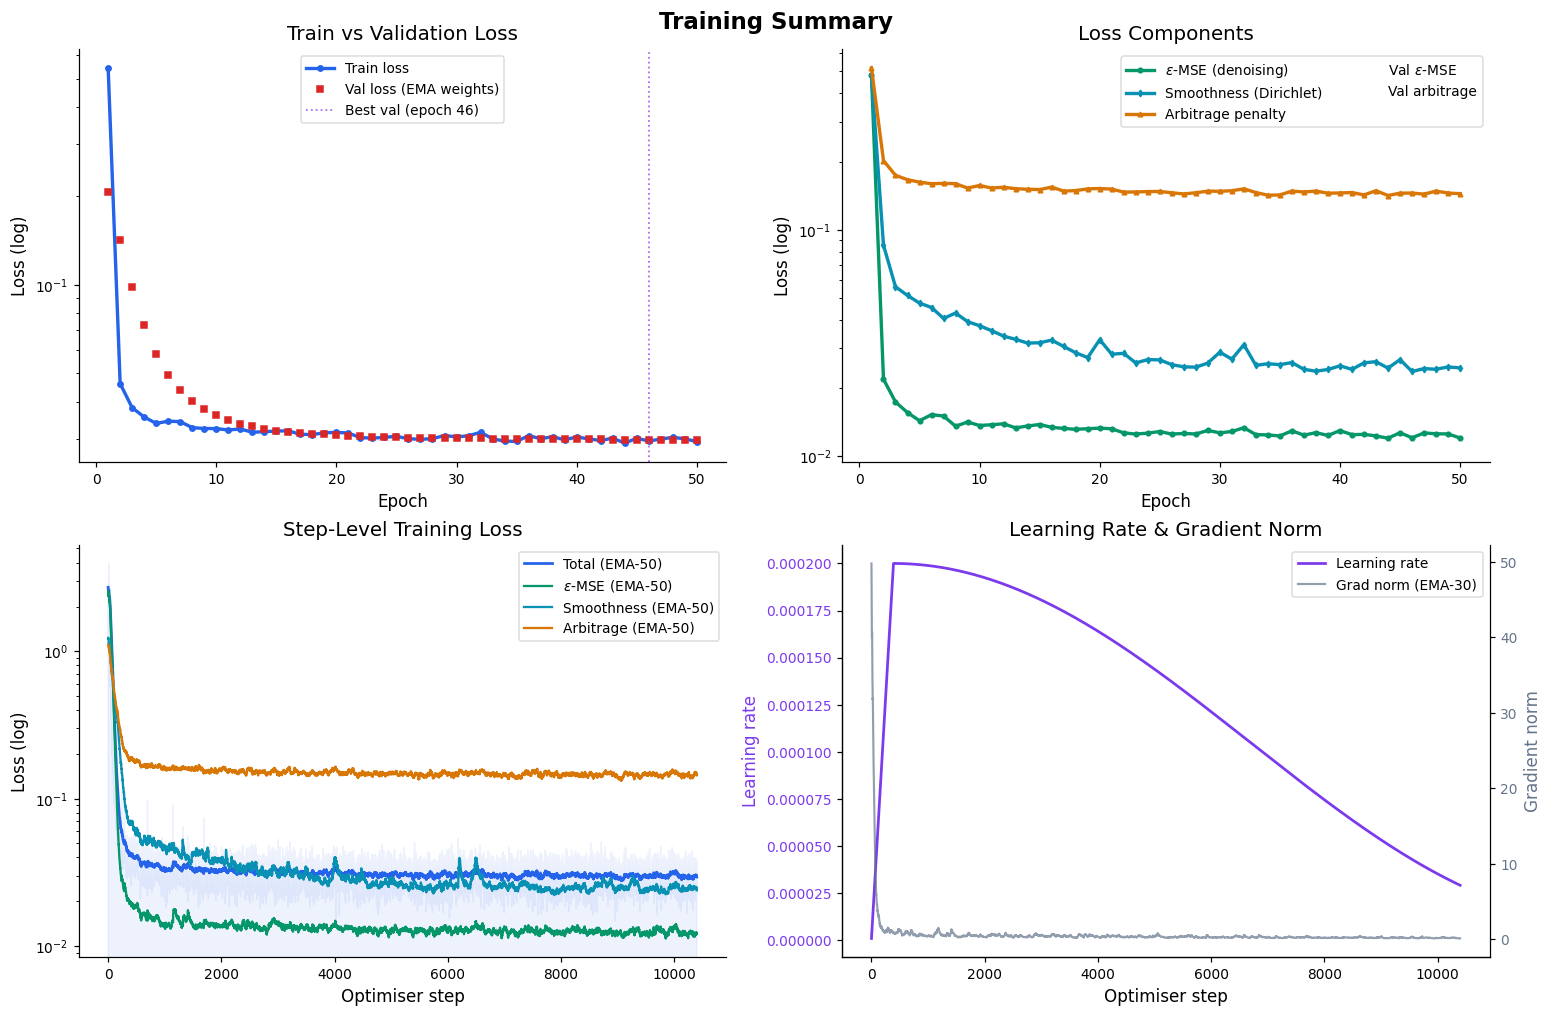

In [11]:
def _ema(series: np.ndarray, span: int = 50) -> np.ndarray:
    return pd.Series(series).ewm(span=span, adjust=False).mean().to_numpy()


_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.85",
}

with plt.rc_context(_STYLE):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    epochs = epoch_history_df["epoch"].to_numpy()
    steps_arr = step_history_df["step"].to_numpy()

    ax = axes[0, 0]
    ax.plot(
        epochs, epoch_history_df["loss_mean"], lw=2.2, color="#2563eb", marker="o", markersize=3.5, label="Train loss"
    )
    if "val_loss" in epoch_history_df.columns and epoch_history_df["val_loss"].notna().any():
        ax.plot(
            epochs,
            epoch_history_df["val_loss"],
            lw=2.2,
            color="#dc2626",
            marker="s",
            markersize=3.5,
            linestyle=" ",
            label="Val loss (EMA weights)",
        )
    if best_epoch > 0:
        ax.axvline(best_epoch, color="#9333ea", ls=":", lw=1.2, alpha=0.7, label=f"Best val (epoch {best_epoch})")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Train vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax = axes[0, 1]
    ax.plot(
        epochs,
        epoch_history_df["loss_eps_mean"],
        lw=2.2,
        color="#059669",
        marker="o",
        markersize=3,
        label=r"$\epsilon$-MSE (denoising)",
    )
    ax.plot(
        epochs,
        epoch_history_df["loss_smooth_mean"],
        lw=2.2,
        color="#0891b2",
        marker="d",
        markersize=3,
        label="Smoothness (Dirichlet)",
    )
    ax.plot(
        epochs,
        epoch_history_df["loss_arb_mean"],
        lw=2.2,
        color="#d97706",
        marker="^",
        markersize=3,
        label="Arbitrage penalty",
    )
    if "val_loss_eps" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_eps"],
            lw=1.6,
            color="#059669",
            ls=" ",
            alpha=0.65,
            label=r"Val $\epsilon$-MSE",
        )
    if "val_loss_arb" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_arb"],
            lw=1.6,
            color="#d97706",
            ls=" ",
            alpha=0.65,
            label="Val arbitrage",
        )
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Loss Components")
    ax.legend(ncols=2)
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax = axes[1, 0]
    ax.fill_between(steps_arr, step_history_df["loss"], alpha=0.08, color="#2563eb")
    ax.plot(steps_arr, _ema(step_history_df["loss"].to_numpy()), lw=1.8, color="#2563eb", label="Total (EMA-50)")
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_eps"].to_numpy()),
        lw=1.5,
        color="#059669",
        label=r"$\epsilon$-MSE (EMA-50)",
    )
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_smooth"].to_numpy()),
        lw=1.5,
        color="#0891b2",
        label="Smoothness (EMA-50)",
    )
    ax.plot(
        steps_arr, _ema(step_history_df["loss_arb"].to_numpy()), lw=1.5, color="#d97706", label="Arbitrage (EMA-50)"
    )
    ax.set_yscale("log")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Step-Level Training Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax = axes[1, 1]
    color_lr, color_gn = "#7c3aed", "#64748b"
    ax.plot(steps_arr, step_history_df["lr"], lw=1.8, color=color_lr, label="Learning rate")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Learning rate", color=color_lr)
    ax.tick_params(axis="y", labelcolor=color_lr)
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax2 = ax.twinx()
    ax2.plot(
        steps_arr,
        _ema(step_history_df["grad_norm"].to_numpy(), span=30),
        lw=1.4,
        color=color_gn,
        alpha=0.7,
        label="Grad norm (EMA-30)",
    )
    ax2.set_ylabel("Gradient norm", color=color_gn)
    ax2.tick_params(axis="y", labelcolor=color_gn)
    ax2.spines["right"].set_visible(True)
    ax2.spines["top"].set_visible(False)
    ax.set_title("Learning Rate & Gradient Norm")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    fig.suptitle("Training Summary", fontsize=15, fontweight="bold", y=1.01)
    fig.savefig("training_loss_curves.pdf", format="pdf", bbox_inches="tight")
    plt.show()

## Save checkpoint

Persist the trained weights, optimiser state, loss histories

In [12]:
checkpoint_path = CHECKPOINT_DIR / "diffusion_unet.pt"
config_path = CHECKPOINT_DIR / "training_config.json"
step_csv_path = CHECKPOINT_DIR / "training_step_history.csv"
epoch_csv_path = CHECKPOINT_DIR / "training_epoch_history.csv"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_timesteps": SCHEDULER_TIMESTEPS,
        "unet_kwargs": UNET_KWARGS,
        "grid_shape": tuple(GRID.shape),
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "arbitrage_lambda": ARBITRAGE_LAMBDA,
        "arbitrage_schedule": ARBITRAGE_SCHEDULE,
        "smoothness_lambda": SMOOTHNESS_LAMBDA,
        "smoothness_schedule": SMOOTHNESS_SCHEDULE,
        "spot_ref": SPOT_REF,
        "rate_ref": RATE_REF,
        "seed": SEED,
        "conditional": True,
        "cond_channels": int(UNET_KWARGS.get("cond_channels", 0)),
    },
    checkpoint_path,
)
config_path.write_text(
    json.dumps(
        {
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "scheduler_timesteps": SCHEDULER_TIMESTEPS,
            "arbitrage_lambda": ARBITRAGE_LAMBDA,
            "arbitrage_schedule": ARBITRAGE_SCHEDULE,
            "smoothness_lambda": SMOOTHNESS_LAMBDA,
            "smoothness_schedule": SMOOTHNESS_SCHEDULE,
            "unet_kwargs": UNET_KWARGS,
            "grid_shape": list(GRID.shape),
            "training_pool_size": int(n_total),
            "spot_ref": SPOT_REF,
            "rate_ref": RATE_REF,
            "holdout_curr_date": str(holdout_curr_date.date()),
            "holdout_next_date": str(holdout_next_date.date()),
            "snapshot_t": list(snapshot_t.tolist()),
            "epochs_for_snapshots": list(epochs_for_snapshots),
            "seed": SEED,
            "conditional": True,
        },
        indent=2,
    ),
    encoding="utf-8",
)
step_history_df.to_csv(step_csv_path, index=False)
epoch_history_df.to_csv(epoch_csv_path, index=False)

print(f"saved checkpoint: {checkpoint_path.relative_to(REPO_ROOT)}")
print(f"saved config : {config_path.relative_to(REPO_ROOT)}")
print(f"saved step log : {step_csv_path.relative_to(REPO_ROOT)}")
print(f"saved epoch log : {epoch_csv_path.relative_to(REPO_ROOT)}")

saved checkpoint: data/processed/checkpoints/diffusion_unet.pt
saved config : data/processed/checkpoints/training_config.json
saved step log : data/processed/checkpoints/training_step_history.csv
saved epoch log : data/processed/checkpoints/training_epoch_history.csv
